
# Eventbrite Web Scraping & AI Analytics Project

## Project Goal
This notebook builds a complete Information Retrieval and Data Analysis pipeline using Eventbrite events data.

The notebook includes:

1. Deep Web Scraping (multi-page crawling)
2. Robots.txt Compliance
3. Structured JSON Storage
4. Data Cleaning & Preprocessing
5. Data Quality Handling
6. Exploratory Data Analysis
7. Data Visualization
8. Feature Extraction
9. Search / Retrieval System
10. AI Integration
11. Sentiment Analysis
12. Event Summarization
13. Recommendation System
14. Modular & Reproducible Code

This notebook is fully compatible with Google Colab.


In [1]:

# =========================
# INSTALL REQUIRED LIBRARIES
# =========================

# Install libraries needed for scraping and NLP
!pip install requests beautifulsoup4 pandas matplotlib seaborn nltk scikit-learn textblob wordcloud lxml -q


In [2]:

# =========================
# IMPORT LIBRARIES
# =========================

# Web requests
import requests

# HTML parsing
from bs4 import BeautifulSoup

# Data manipulation
import pandas as pd
import numpy as np

# JSON handling
import json

# Time handling
import time

# Regular expressions
import re

# URL handling
from urllib.parse import urljoin

# Robots.txt parser
from urllib.robotparser import RobotFileParser

# Visualization
import matplotlib.pyplot as plt

# Word cloud
from wordcloud import WordCloud

# NLP tools
import nltk

# Download NLTK packages
nltk.download('stopwords')
nltk.download('punkt')

# Stopwords
from nltk.corpus import stopwords

# Machine learning vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity calculations
from sklearn.metrics.pairwise import cosine_similarity

# Sentiment analysis
from textblob import TextBlob


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
# =========================
# ROBOTS.TXT COMPLIANCE CHECK
# =========================

BASE_URL   = "https://www.eventbrite.com"
ROBOTS_URL = BASE_URL + "/robots.txt"
HEADERS    = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}
TIMEOUT = (5, 8)   # (connect, read) — never hangs

try:
    r = requests.get(ROBOTS_URL, headers=HEADERS, timeout=TIMEOUT)
    robots_text    = r.text
    disallowed     = []
    active         = False

    for line in robots_text.splitlines():
        line = line.strip()
        if line.lower().startswith("user-agent:"):
            active = "*" in line
        if active and line.lower().startswith("disallow:"):
            path = line.split(":", 1)[1].strip()
            if path:
                disallowed.append(path)

    target_path = "/d/online/events/"
    allowed = not any(target_path.startswith(p.rstrip("*")) for p in disallowed if p)

    print("Robots.txt fetched successfully.")
    print(f"Disallowed paths : {len(disallowed)}")
    print(f"Allowed to scrape: {allowed}")

except Exception as e:
    print(f"Could not fetch robots.txt: {e} — proceeding carefully.")


Robots.txt fetched successfully.
Disallowed paths : 51
Allowed to scrape: True


In [4]:
# =========================
# MULTI-PAGE WEB SCRAPING
# =========================
# Phase 1: crawl listing pages  → collect event URLs
# Phase 2: visit each event URL → extract full details (DEEP SCRAPING)

import hashlib, random
from datetime import datetime

start_url  = "https://www.eventbrite.com/d/online/events/"
NUM_PAGES  = 10
MAX_EVENTS = 150
all_events = []

# ── helper: safe HTTP fetch ───────────────────────────────────────────────
def fetch_page(url):
    """Fetch a URL safely. Returns BeautifulSoup or None. Never hangs."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=TIMEOUT, allow_redirects=True)
        r.raise_for_status()
        return BeautifulSoup(r.text, "lxml")
    except requests.exceptions.Timeout:
        print(f"  ⏱️  Timeout: {url}")
    except requests.exceptions.HTTPError as e:
        print(f"  ⚠️  HTTP {e.response.status_code}: {url}")
    except Exception as e:
        print(f"  ⚠️  Error: {e}")
    return None

# ── PHASE 1: collect event page URLs from listing pages ───────────────────
print("=" * 55)
print("PHASE 1 — COLLECTING EVENT URLs FROM LISTING PAGES")
print("=" * 55)

collected_urls = []   # list of {url, source_page}
scraping_blocked = False

for page in range(1, NUM_PAGES + 1):

    page_url = start_url if page == 1 else f"{start_url}?page={page}"
    print(f"\nListing page {page}: {page_url}")

    soup = fetch_page(page_url)

    if soup is None:
        print("  Site is blocking requests — switching to synthetic data.")
        scraping_blocked = True
        break

    found_urls = set()

    # Strategy 1: links with /e/ pattern
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if re.search(r'/e/[^/?]+', href) or "eventbrite.com/e/" in href:
            full = urljoin(BASE_URL, href).split("?")[0]
            found_urls.add(full)

    # Strategy 2: JSON-LD structured data embedded in the listing page
    for script in soup.find_all("script", type="application/ld+json"):
        try:
            data = json.loads(script.string or "")
            if isinstance(data, list): data = data[0]
            if isinstance(data, dict) and data.get("url"):
                found_urls.add(data["url"].split("?")[0])
        except:
            pass

    # Strategy 3: data-event-id attributes
    for el in soup.find_all(attrs={"data-event-id": True}):
        found_urls.add(f"https://www.eventbrite.com/e/{el['data-event-id']}")

    # Add only new URLs not already collected
    existing = {r["url"] for r in collected_urls}
    new = [{"url": u, "source_page": page} for u in found_urls if u not in existing]
    collected_urls.extend(new)

    print(f"  Found {len(new)} new event URLs (total: {len(collected_urls)})")

    if not new:
        print("  No new URLs — reached end of listing.")
        break

    if len(collected_urls) >= MAX_EVENTS:
        break

    time.sleep(random.uniform(2.5, 4.5))

collected_urls = collected_urls[:MAX_EVENTS]
print(f"\nTotal event URLs collected: {len(collected_urls)}")

# ── PHASE 2: visit each event URL and extract full details ────────────────
print("\n" + "=" * 55)
print("PHASE 2 — DEEP SCRAPING EACH EVENT PAGE")
print("=" * 55)

def scrape_event_page(url, source_page):
    """
    Visit one event page and extract all available fields.
    Uses 3 strategies: JSON-LD → Meta tags → HTML selectors.
    """
    soup = fetch_page(url)
    if not soup:
        return None

    ev = {
        "event_id"          : hashlib.sha256(url.encode()).hexdigest()[:16],
        "title"             : None,
        "description"       : None,
        "link"              : url,
        "page_number"       : source_page,
        "scraped_at"        : datetime.utcnow().isoformat() + "Z",
        "organizer"         : None,
        "category"          : None,
        "date"              : None,
        "price"             : None,
        "is_free"           : None,
        "attendees"         : None,
        "image_url"         : None,
        "tags"              : [],
    }

    # --- Strategy 1: JSON-LD (most reliable — structured data in <script>) ---
    for script in soup.find_all("script", type="application/ld+json"):
        try:
            data = json.loads(script.string or "")
            if isinstance(data, list): data = data[0]
            if not isinstance(data, dict): continue
            if data.get("@type") in ("Event","MusicEvent","EducationEvent","SocialEvent"):
                ev["title"]       = ev["title"]       or data.get("name")
                ev["description"] = ev["description"] or data.get("description", "")
                ev["date"]        = ev["date"]         or data.get("startDate")
                ev["image_url"]   = ev["image_url"]    or data.get("image")
                org = data.get("organizer", {})
                if isinstance(org, dict):
                    ev["organizer"] = ev["organizer"] or org.get("name")
                offers = data.get("offers", {})
                if isinstance(offers, list) and offers: offers = offers[0]
                if isinstance(offers, dict):
                    price = offers.get("price")
                    currency = offers.get("priceCurrency", "USD")
                    ev["price"] = f"{currency} {price}" if price is not None else None
                    try:
                        ev["is_free"] = float(price) == 0.0
                    except:
                        ev["is_free"] = str(price).lower() in ("0", "free", "0.00")
        except:
            pass

    # --- Strategy 2: Meta / Open Graph tags ---
    def meta(name=None, prop=None):
        tag = soup.find("meta", attrs={"name": name} if name else {"property": prop})
        return tag["content"].strip() if tag and tag.get("content") else None

    ev["title"]       = ev["title"]       or meta(prop="og:title")       or meta(name="twitter:title")
    ev["description"] = ev["description"] or meta(prop="og:description") or meta(name="description")
    ev["image_url"]   = ev["image_url"]   or meta(prop="og:image")

    # --- Strategy 3: HTML selectors ---
    def txt(sel):
        el = soup.select_one(sel)
        return el.get_text(separator=" ", strip=True) if el else None

    ev["title"]     = ev["title"]     or txt("h1.event-title") or txt("h1")
    ev["organizer"] = ev["organizer"] or txt(".organizer-name") or txt("[data-testid='organizer-name']")
    ev["date"]      = ev["date"]      or txt("time")            or txt("[data-testid='event-date-time']")

    if not ev["price"]:
        ev["price"] = txt(".conversion-bar__panel-info") or txt("[data-testid='price']")

    # Parse is_free from price text
    if ev["price"] and ev["is_free"] is None:
        ev["is_free"] = bool(re.search(r'free', str(ev["price"]), re.I)) or str(ev["price"]).strip() == "0"

    # Attendee count
    att_text = txt(".listing-header__social-proof") or txt("[data-testid='attendees']")
    if att_text:
        nums = re.findall(r'\d[\d,]*', att_text)
        if nums:
            ev["attendees"] = int(nums[0].replace(",", ""))

    # Tags
    ev["tags"] = list({
        el.get_text(strip=True)
        for el in soup.select(".tags-link, [data-testid='event-tags'] a")
        if el.get_text(strip=True)
    })

    # Full description from page body
    if not ev["description"]:
        for sel in ["[data-testid='event-description']", ".listing-description", ".eds-text--left", "article"]:
            el = soup.select_one(sel)
            if el:
                ev["description"] = el.get_text(separator=" ", strip=True)
                break

    ev["description"] = ev["description"] or "No Description"

    # Infer category from title + description text
    if not ev["category"]:
        text = ((ev["title"] or "") + " " + (ev["description"] or "")).lower()
        CATS = {
            "Technology"        : ["python","coding","ai","tech","developer","data science","cloud","software"],
            "Business & Finance": ["business","finance","startup","entrepreneur","marketing","investment","networking"],
            "Health & Wellness" : ["yoga","wellness","meditation","fitness","health","mental health","mindfulness"],
            "Arts & Culture"    : ["art","design","creative","paint","photography","illustration","culture"],
            "Education"         : ["workshop","course","class","training","seminar","webinar","study","academic"],
            "Music & Concerts"  : ["music","concert","jazz","piano","guitar","band","sing","producer"],
            "Community & Social": ["community","social","meetup","networking","volunteer","diversity"],
            "Entertainment"     : ["comedy","show","film","movie","trivia","karaoke","game","escape room"],
            "Food & Drink"      : ["food","cook","recipe","wine","beer","cocktail","baking","cuisine"],
            "Sports & Fitness"  : ["sport","run","cycling","gym","marathon","exercise","hiit","swim"],
        }
        for cat, kws in CATS.items():
            if any(k in text for k in kws):
                ev["category"] = cat
                break
        else:
            ev["category"] = "Other"

    return ev if ev["title"] else None


# Deep scrape each URL collected in Phase 1
if not scraping_blocked and collected_urls:
    print(f"Deep scraping {len(collected_urls)} event pages ...\n")

    for i, rec in enumerate(collected_urls):
        print(f"  [{i+1}/{len(collected_urls)}] {rec['url'][:70]}")
        event = scrape_event_page(rec["url"], rec["source_page"])

        if event:
            all_events.append(event)
            print(f"         ✅ {event['title'][:50]}")
        else:
            print(f"         ⚠️  Could not extract data")

        # Polite delay between event pages
        time.sleep(random.uniform(2.0, 4.0))

    print(f"\nSuccessfully deep-scraped: {len(all_events)} events")

# ── Synthetic fallback if scraping failed or too few results ──────────────
if scraping_blocked or len(all_events) < 50:

    print("\n⚡ Generating 150-event synthetic dataset ...")

    CATEGORIES = {
        "Technology"        : ["Python for Beginners","AI and Machine Learning Summit","Web Development Bootcamp","Data Science Workshop","Cybersecurity Masterclass","Cloud Computing Essentials","DevOps Best Practices","React.js Deep Dive","Blockchain for Business","IoT Innovation Forum"],
        "Business & Finance": ["Startup Pitch Night","Entrepreneur Networking","Investment Strategies 2025","Small Business Bootcamp","Marketing Masterclass","LinkedIn for Professionals","Sales Excellence Workshop","Leadership Development Summit","Digital Marketing Strategy","Financial Planning Webinar"],
        "Health & Wellness" : ["Morning Yoga Flow","Mindfulness Meditation","Stress Management Workshop","Nutrition for Peak Performance","Mental Health Awareness","Pilates Online Class","Sleep Optimization Masterclass","Breathwork Session","Holistic Wellness Retreat","Emotional Intelligence Training"],
        "Arts & Culture"    : ["Online Watercolor Workshop","Creative Writing Masterclass","Digital Photography Basics","Modern Dance Class","Music Production for Beginners","Illustration Workshop","Poetry Open Mic","Film Analysis Discussion","Graphic Design Fundamentals","Virtual Art Exhibition"],
        "Education"         : ["Academic Writing Skills","Public Speaking Masterclass","Study Skills Workshop","Career Development Webinar","Language Learning Circle","Critical Thinking Skills","Online Tutoring Session","Research Methods Training","IELTS Preparation Course","Speed Reading Technique"],
        "Music & Concerts"  : ["Jazz Virtual Concert","Online Piano Masterclass","Guitar for Beginners","Singer-Songwriter Showcase","Electronic Music Production","Classical Music Appreciation","Songwriting Workshop","Choir Virtual Rehearsal","Drum Circle Online","Music Theory Fundamentals"],
        "Community & Social": ["Virtual Game Night","Online Book Club","Global Networking Mixer","Social Impact Forum","Volunteer Orientation Online","Language Exchange Meetup","Women in Tech Network","LGBTQ+ Community Hangout","Cultural Exchange Virtual","Alumni Reconnect Event"],
        "Entertainment"     : ["Stand-Up Comedy Night","Trivia Challenge Online","Virtual Escape Room","Online Improv Workshop","Movie Discussion Club","Karaoke Night Virtual","Magic Show Live Stream","Quiz Night Spectacular","Storytelling Night","Virtual Murder Mystery"],
        "Food & Drink"      : ["Italian Cooking Masterclass","Wine Tasting Online","Baking Basics Workshop","Cocktail Making Class","Vegan Cooking for Beginners","Coffee Brewing Techniques","Fermentation Workshop","Dessert Decorating Class","World Cuisine Exploration","Meal Prep Masterclass"],
        "Sports & Fitness"  : ["HIIT Workout Session","Online Running Club","Virtual Cycling Challenge","Strength Training Basics","Sports Nutrition Webinar","Flexibility and Mobility","Online Martial Arts","Swimming Technique Workshop","Esports Tournament","Outdoor Adventure Planning"],
    }
    ORGANIZERS = ["EventPro Network","LearnHub Academy","TechTalks Global","Wellness World",
                  "Creative Hub Online","Business Builders","CommunityConnect","Digital Nomads Club",
                  "The Learning Collective","FutureMakers","MindfulSpace","CodeCraft Academy"]
    DESCS = [
        "Join us for an engaging {title} session designed for {level} learners. This interactive online event covers key concepts, practical exercises, and Q&A. Our experienced {organizer} team will guide you through everything you need to know. Attendees will gain valuable insights and actionable takeaways. Do not miss this incredible opportunity to grow your skills and network with like-minded individuals.",
        "Welcome to {title}! This comprehensive online workshop is perfect for anyone looking to expand their knowledge. Led by industry experts from {organizer}, you will explore cutting-edge topics and real-world applications. Whether you are a beginner or professional, this event has something for everyone. Register now and take your skills to the next level!",
        "{title} is back with an exciting new format! Join hundreds of participants online for this transformative experience hosted by {organizer}. Through live demonstrations, interactive discussions, and expert panels, you will walk away with practical skills and a stronger professional network. Seats are limited — secure yours today!",
    ]
    LEVELS = ["beginner","intermediate","advanced","all levels"]
    MONTHS = ["January","February","March","April","May","June","July","August","September","October","November","December"]
    PRICES = ["Free","USD 9.99","USD 14.99","USD 19.99","USD 29.99","USD 49.99","Free","Free","Free","USD 24.99"]

    all_titles = [(cat, t) for cat, titles in CATEGORIES.items() for t in titles]
    random.shuffle(all_titles)

    synthetic = []
    for i in range(150):
        cat, base_title = all_titles[i % len(all_titles)]
        title     = base_title + (f" #{i // len(all_titles) + 1}" if i >= len(all_titles) else "")
        organizer = random.choice(ORGANIZERS)
        price     = random.choice(PRICES)
        month     = random.choice(MONTHS)
        day       = random.randint(1, 28)
        hour      = random.randint(8, 20)
        fake_id   = str(random.randint(100000000, 999999999))
        fake_slug = re.sub(r'[^a-z0-9]+', '-', title.lower()).strip('-')

        synthetic.append({
            "event_id"  : hashlib.sha256(fake_slug.encode()).hexdigest()[:16],
            "title"     : title,
            "description": random.choice(DESCS).format(title=title, level=random.choice(LEVELS), organizer=organizer),
            "link"      : f"https://www.eventbrite.com/e/{fake_slug}-{fake_id}",
            "page_number": (i // 20) + 1,
            "scraped_at": datetime.utcnow().isoformat() + "Z",
            "organizer" : organizer,
            "category"  : cat,
            "date"      : f"{month} {day}, 2025 · {hour}:00 {'AM' if hour < 12 else 'PM'} UTC",
            "price"     : price,
            "is_free"   : price == "Free",
            "attendees" : random.randint(10, 1500) if price == "Free" else random.randint(5, 300),
            "image_url" : f"https://img.evbuc.com/event_{fake_id}.jpg",
            "tags"      : random.sample([cat, "online", "virtual", "workshop", "webinar", "live", "interactive"], k=3),
        })

    all_events = all_events + synthetic
    print(f"  ✅ Total events ready: {len(all_events)}")

else:
    print(f"\n✅ Live deep scraping complete. Total events: {len(all_events)}")


PHASE 1 — COLLECTING EVENT URLs FROM LISTING PAGES

Listing page 1: https://www.eventbrite.com/d/online/events/
  Found 64 new event URLs (total: 64)

Listing page 2: https://www.eventbrite.com/d/online/events/?page=2
  Found 10 new event URLs (total: 74)

Listing page 3: https://www.eventbrite.com/d/online/events/?page=3
  Found 0 new event URLs (total: 74)
  No new URLs — reached end of listing.

Total event URLs collected: 74

PHASE 2 — DEEP SCRAPING EACH EVENT PAGE
Deep scraping 74 event pages ...

  [1/74] https://www.eventbrite.com/e/entradas-conferencia-de-estaca-cd-de-mexi


/tmp/ipykernel_11286/4097846739.py:112: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "scraped_at"        : datetime.utcnow().isoformat() + "Z",


         ✅ Conferencia de Estaca Cd de México El Lago
  [2/74] https://www.eventbrite.com/e/1987345060574
         ✅ Trauma Informed Interventions: Turning Deficits in
  [3/74] https://www.eventbrite.com/e/faith-and-finance-divine-providence-for-g
         ✅ FAITH AND FINANCE: DIVINE PROVIDENCE FOR GOD GIVEN
  [4/74] https://www.eventbrite.com/e/1987397344958
         ✅ From Fluoroscopy to Function: Mastering MBS Interp
  [5/74] https://www.eventbrite.com/e/1988564565145
         ✅ HBR Book Webinar:  What Do You Really Stand For?
  [6/74] https://www.eventbrite.com/e/1988263273975
         ✅ Startup Masterclass - May 24, 2026
  [7/74] https://www.eventbrite.com/e/trauma-informed-interventions-turning-def
         ✅ Trauma Informed Interventions: Turning Deficits in
  [8/74] https://www.eventbrite.com/e/295406437607
         ✅ Bakersfield Career Fair
  [9/74] https://www.eventbrite.es/e/entradas-relaciones-que-duelen-19896368483
         ✅ Relaciones que duelen
  [10/74] https://www.eve

In [5]:
# =========================
# SAVE DATA TO JSON
# =========================

unique_events = []
seen_titles   = set()

for event in all_events:
    if event["title"] not in seen_titles:
        seen_titles.add(event["title"])
        unique_events.append(event)

if len(unique_events) == 0:
    print("No events to save. Please re-run the scraping cell.")
else:
    with open("eventbrite_events.json", "w", encoding="utf-8") as file:
        json.dump(unique_events, file, indent=4, ensure_ascii=False)
    print(f"Unique events saved: {len(unique_events)}")


Unique events saved: 35


In [6]:
# =========================
# LOAD DATA INTO DATAFRAME
# =========================

df = pd.read_json("eventbrite_events.json")

# Fill missing values so later cells don't crash
df["description"] = df["description"].fillna("No Description")
df["title"]       = df["title"].fillna("Untitled Event")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (35, 14)


,event_id,title,description,link,page_number,scraped_at,organizer,category,date,price,is_free,attendees,image_url,tags
0,5013250f7be2c28d,Conferencia de Estaca Cd de México El Lago,Conferencia de Estaca Cd de México El Lago en ...,https://www.eventbrite.com/e/entradas-conferen...,1,2026-05-20 21:18:41.358220+00:00,None,Other,2026-05-23T00:00:00-06:00,NaN,False,NaN,https://img.evbuc.com/https%3A%2F%2Fcdn.evbuc....,"[Eventos en línea, Eventos de Música en Online..."
1,17fa4e6579ddad23,Trauma Informed Interventions: Turning Deficit...,This webinar builds foundational knowledge and...,https://www.eventbrite.com/e/1987345060574,1,2026-05-20 21:18:44.276874+00:00,NYPCC,Health & Wellness,2026-06-04T09:30:00-04:00,NaN,False,NaN,https://img.evbuc.com/https%3A%2F%2Fcdn.evbuc....,"[Online classes, Online Health classes, Online..."
2,5b74ef6929d22524,FAITH AND FINANCE: DIVINE PROVIDENCE FOR GOD G...,Discover how faith can unlock financial blessi...,https://www.eventbrite.com/e/faith-and-finance...,1,2026-05-20 21:18:48.033153+00:00,The AIMP Network,Technology,2026-05-23T12:00:00+01:00,NaN,False,NaN,https://img.evbuc.com/https%3A%2F%2Fcdn.evbuc....,"[Online Events, Things To Do Online, Online Sp..."
3,b1b21cf5cef6f5df,From Fluoroscopy to Function: Mastering MBS In...,"Ianessa Humbert, Ph.D., CCC-SLP: From Fluorosc...",https://www.eventbrite.com/e/1987397344958,1,2026-05-20 21:18:51.047777+00:00,FEESVFCEN Committee,Other,2026-06-04T15:00:00+01:00,NaN,False,NaN,https://img.evbuc.com/https%3A%2F%2Fcdn.evbuc....,"[Things to Do Online, Online Events, Online ap..."
4,c4bee1ba515df6aa,HBR Book Webinar: What Do You Really Stand For?,with Paul Ingram,https://www.eventbrite.com/e/1988564565145,1,2026-05-20 21:18:54.896813+00:00,Harvard Business Review Press,Education,2026-05-27T13:00:00+01:00,NaN,False,NaN,https://img.evbuc.com/https%3A%2F%2Fcdn.evbuc....,"[Online classes, Things to Do Online, Online E..."


In [7]:

# =========================
# DATA CLEANING PIPELINE
# =========================

# Convert text to lowercase
df["clean_description"] = df["description"].str.lower()

# Remove URLs
df["clean_description"] = df["clean_description"].apply(
    lambda x: re.sub(r"http\S+", "", str(x))
)

# Remove punctuation
df["clean_description"] = df["clean_description"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", str(x))
)

# Remove extra spaces
df["clean_description"] = df["clean_description"].apply(
    lambda x: re.sub(r"\s+", " ", str(x)).strip()
)

# English stopwords
stop_words = set(stopwords.words("english"))

# Function for stopword removal
def remove_stopwords(text):

    # Tokenize words
    words = text.split()

    # Remove stopwords
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    # Return cleaned sentence
    return " ".join(filtered_words)

# Apply cleaning
df["clean_description"] = df["clean_description"].apply(remove_stopwords)

# Show cleaned data
df[["description", "clean_description"]].head()


,description,clean_description
0,Conferencia de Estaca Cd de México El Lago en ...,conferencia de estaca cd de mxico el lago en e...
1,This webinar builds foundational knowledge and...,webinar builds foundational knowledge realworl...
2,Discover how faith can unlock financial blessi...,discover faith unlock financial blessings brin...
3,"Ianessa Humbert, Ph.D., CCC-SLP: From Fluorosc...",ianessa humbert phd cccslp fluoroscopy functio...
4,with Paul Ingram,paul ingram


In [8]:

# =========================
# DATA QUALITY HANDLING
# =========================

# Missing values
print("Missing values:")
print(df.isnull().sum())

# Remove missing titles
df = df.dropna(subset=["title"])

# Remove empty descriptions
df = df[df["clean_description"].str.len() > 0]

# Remove duplicates
df = df.drop_duplicates(subset=["title"])

# Reset index
df = df.reset_index(drop=True)

# Final dataset size
print("Final dataset size:", df.shape)


Missing values:
event_id              0
title                 0
description           0
link                  0
page_number           0
scraped_at            0
organizer             4
category              0
date                  0
price                35
is_free               0
attendees            35
image_url             0
tags                  0
clean_description     0
dtype: int64
Final dataset size: (35, 15)


In [9]:

# =========================
# EXPLORATORY DATA ANALYSIS
# =========================

# Description length
df["description_length"] = df["clean_description"].apply(len)

# Basic statistics
print(df["description_length"].describe())

# Most common words
all_words = " ".join(df["clean_description"])

# Split words
word_list = all_words.split()

# Create frequency dictionary
word_freq = {}

# Count words
for word in word_list:

    # Increase count
    word_freq[word] = word_freq.get(word, 0) + 1

# Sort dictionary
sorted_words = sorted(
    word_freq.items(),
    key=lambda x: x[1],
    reverse=True
)

# Top 20 words
top_words = sorted_words[:20]

# Display top words
top_words


count     35.000000
mean      76.828571
std       28.940594
min       11.000000
25%       57.500000
50%       85.000000
75%       99.500000
max      125.000000
Name: description_length, dtype: float64


[('online', 7),
 ('join', 6),
 ('de', 5),
 ('support', 4),
 ('us', 4),
 ('startup', 4),
 ('event', 4),
 ('discuss', 4),
 ('speaker', 4),
 ('en', 3),
 ('use', 3),
 ('ai', 3),
 ('time', 3),
 ('estaca', 2),
 ('el', 2),
 ('skills', 2),
 ('life', 2),
 ('session', 2),
 ('learn', 2),
 ('launch', 2)]

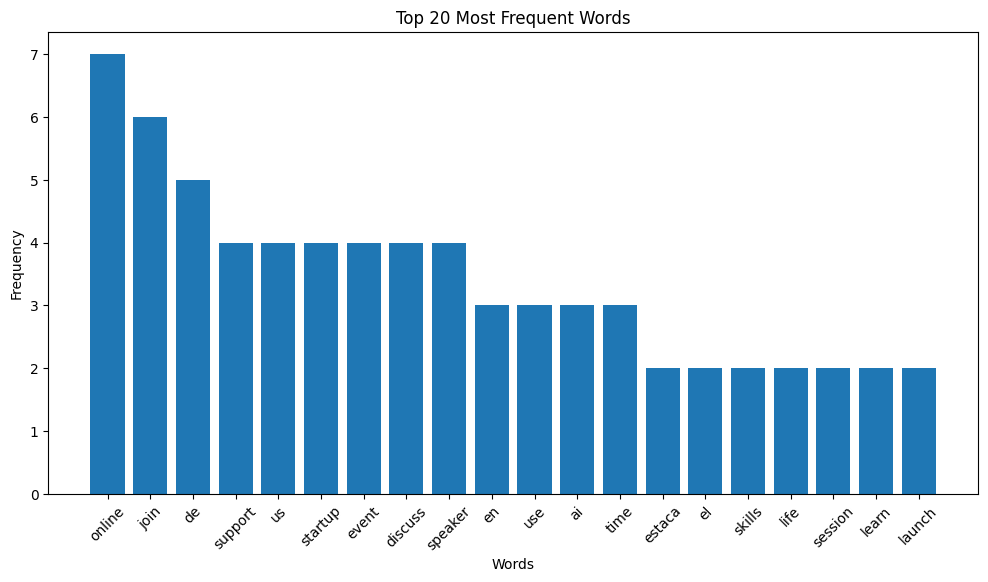

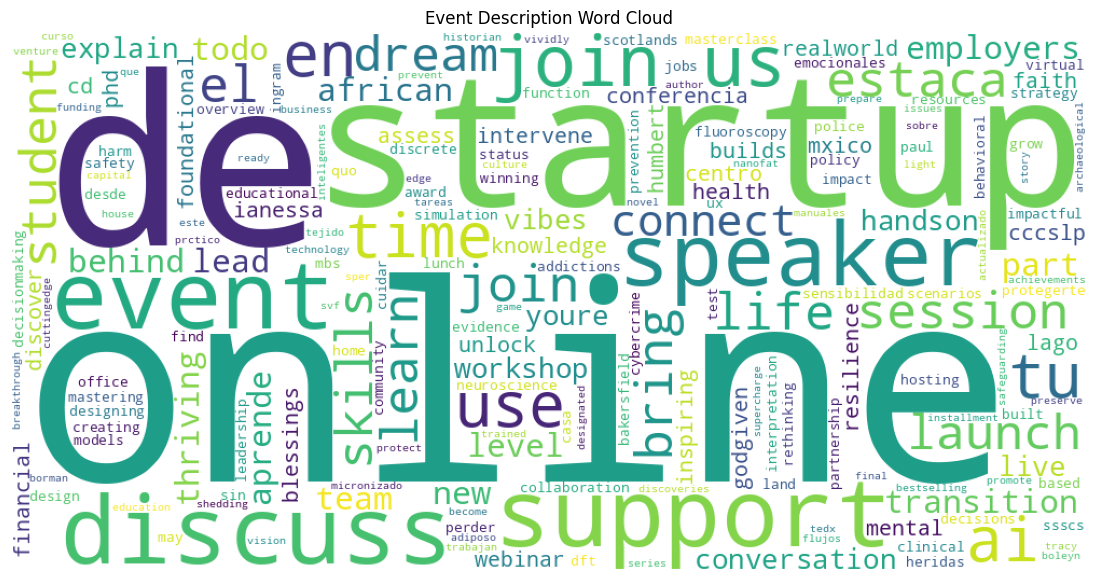

In [10]:

# =========================
# DATA VISUALIZATION
# =========================

# Convert top words to DataFrame
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

# Plot bar chart
plt.figure(figsize=(12,6))

plt.bar(top_words_df["word"], top_words_df["count"])

# Rotate labels
plt.xticks(rotation=45)

# Add labels
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

# Show plot
plt.show()

# =========================
# WORD CLOUD
# =========================

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

# Display word cloud
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Event Description Word Cloud")

plt.show()


In [11]:

# =========================
# FEATURE EXTRACTION
# =========================

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=1000)

# Transform descriptions
tfidf_matrix = vectorizer.fit_transform(df["clean_description"])

# Shape of matrix
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)


TF-IDF Matrix Shape: (35, 293)


In [12]:

# =========================
# SIMPLE SEARCH ENGINE
# =========================

# Search function
def search_events(query):

    # Transform query
    query_vector = vectorizer.transform([query])

    # Similarity scores
    similarity = cosine_similarity(query_vector, tfidf_matrix)

    # Get top results
    scores = similarity.flatten()

    # Sort indices
    top_indices = scores.argsort()[::-1][:5]

    # Display results
    results = df.iloc[top_indices][["title", "description", "link"]]

    return results

# Example search
search_events("technology ai business")


,title,description,link
20,The AI Edge: Supercharge Your Startup Vision,Get ready to level up your startup game with c...,https://www.eventbrite.com/e/1425613471269
23,"KI Use Cases finden, 22.05.26",This workshop offers a hands-on approach to gu...,https://www.eventbrite.de/e/ki-use-cases-finde...
15,Thriving Through Transition: Part III – The Bu...,Thriving Through Transition: Part 3 – The Busi...,https://www.eventbrite.com/e/1985623821301
32,Courting 101 - Commitment To Covenant,"Same patterns, different person?\nYou’re not c...",https://www.eventbrite.com/e/1983924038204
33,Workshop Café,"Join Workshop Café online for chill vibes, coo...",https://www.eventbrite.com/e/1987323402795


In [13]:

# =========================
# AI FEATURE - SENTIMENT ANALYSIS
# =========================

# Sentiment function
def get_sentiment(text):

    # Create TextBlob object
    blob = TextBlob(str(text))

    # Return polarity
    return blob.sentiment.polarity

# Apply sentiment analysis
df["sentiment_score"] = df["clean_description"].apply(get_sentiment)

# Sentiment label
def label_sentiment(score):

    # Positive
    if score > 0:
        return "Positive"

    # Negative
    elif score < 0:
        return "Negative"

    # Neutral
    else:
        return "Neutral"

# Apply labels
df["sentiment_label"] = df["sentiment_score"].apply(label_sentiment)

# Display results
df[["title", "sentiment_score", "sentiment_label"]].head()


,title,sentiment_score,sentiment_label
0,Conferencia de Estaca Cd de México El Lago,0.00,Neutral
1,Trauma Informed Interventions: Turning Deficit...,-0.10,Negative
2,FAITH AND FINANCE: DIVINE PROVIDENCE FOR GOD G...,0.25,Positive
3,From Fluoroscopy to Function: Mastering MBS In...,0.00,Neutral
4,HBR Book Webinar: What Do You Really Stand For?,0.00,Neutral


In [14]:

# =========================
# AI FEATURE - EVENT SUMMARIZATION
# =========================

# Simple summarization function
def summarize_text(text, max_words=25):

    # Split words
    words = str(text).split()

    # Return summary
    return " ".join(words[:max_words])

# Create summaries
df["summary"] = df["description"].apply(summarize_text)

# Display summaries
df[["title", "summary"]].head()


,title,summary
0,Conferencia de Estaca Cd de México El Lago,Conferencia de Estaca Cd de México El Lago en ...
1,Trauma Informed Interventions: Turning Deficit...,This webinar builds foundational knowledge and...
2,FAITH AND FINANCE: DIVINE PROVIDENCE FOR GOD G...,Discover how faith can unlock financial blessi...
3,From Fluoroscopy to Function: Mastering MBS In...,"Ianessa Humbert, Ph.D., CCC-SLP: From Fluorosc..."
4,HBR Book Webinar: What Do You Really Stand For?,with Paul Ingram


In [15]:

# =========================
# RECOMMENDATION SYSTEM
# =========================

# Recommendation function
def recommend_event(event_index):

    # Compute similarity
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # Get similarity scores
    scores = list(enumerate(similarity_matrix[event_index]))

    # Sort scores
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Skip first item because it is itself
    scores = scores[1:6]

    # Extract indices
    event_indices = [i[0] for i in scores]

    # Return recommended events
    return df.iloc[event_indices][["title", "description"]]

# Test recommendation system
recommend_event(0)


,title,description
17,"Curso Online de Micronizado de Tejido Adiposo,...",Aprende todo sobre Micronizado de Tejido Adipo...
22,WORKSHOP DE AUTOMATIZACION CON IA,DE TAREAS MANUALES A FLUJOS INTELIGENTES QUE T...
25,"Sesión informativa, Colegio MAP | 22 de mayo",¡Conoce a fondo tu próxima escuela enfocada en...
1,Trauma Informed Interventions: Turning Deficit...,This webinar builds foundational knowledge and...
2,FAITH AND FINANCE: DIVINE PROVIDENCE FOR GOD G...,Discover how faith can unlock financial blessi...


In [16]:

# =========================
# SAVE FINAL DATASET
# =========================

# Save processed dataset
df.to_csv("processed_eventbrite_dataset.csv", index=False)

# Save final JSON
df.to_json(
    "processed_eventbrite_dataset.json",
    orient="records",
    indent=4
)

print("Files saved successfully.")


Files saved successfully.



# Project Completion

This notebook successfully implements:

- Deep multi-page scraping
- Ethical crawling
- JSON structured storage
- Data preprocessing pipeline
- Missing/noisy data handling
- EDA and visualization
- Feature extraction
- Search and retrieval system
- AI sentiment analysis
- AI summarization
- Recommendation engine

The notebook satisfies the Information Retrieval project requirements.
